In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('train_data.csv')
y = df['style'].map({'photo': 0, 'cartoon': 1})
x = df['image_path']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=100/981)
len(x_train), len(x_test)

(881, 100)

In [141]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)

In [142]:
from torch import nn
for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 1)

for param in model.fc.parameters():
    param.requires_grad = True

device = 'cuda'
model = model.to(device)

sum(p.numel() for p in model.parameters() if p.requires_grad)

513

In [135]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

transforms = ResNet18_Weights.DEFAULT.transforms()

class ImageDataset(Dataset):
    def __init__(self, img_paths, labels, transforms):
        super().__init__()
        self.img_paths = img_paths
        self.labels = labels
        self.transforms = transforms
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
        img = Image.open(self.img_paths[index]).convert('RGB')
        tensor_img = self.transforms(img)
        return tensor_img, torch.tensor(self.labels[index], dtype=torch.float32)
    
train_loader = DataLoader(ImageDataset(x_train.tolist(), y_train.tolist(), transforms), batch_size=16, shuffle=True)
test_loader = DataLoader(ImageDataset(x_test.tolist(), y_test.tolist(), transforms), batch_size=16, shuffle=False)

In [ ]:
from tqdm import tqdm
criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-3)
epochs = 20

for epoch in tqdm(range(epochs)):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optim.step()
        optim.zero_grad()
        train_loss += loss.item() * len(labels)
        train_acc += torch.sum((torch.sigmoid(logits) > 0.5).int() == labels).item()

    train_loss /= len(y_train)
    train_acc /= len(y_train)

    model.eval()
    with torch.no_grad():
        test_loss, test_acc = 0.0, 0.0
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).squeeze(1)
            loss = criterion(logits, labels)

            test_loss += loss.item() * len(labels)
            test_acc += sum((torch.sigmoid(logits) > 0.5).int() == labels)

        test_loss /= len(y_test)
        test_acc /= len(y_test)

    print(f'Epoch {epoch}/{epochs} | Train Acc {train_acc:.2f} | Test Acc {test_acc:.2f}')


In [164]:
import torch
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Identity()
model = model.to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [165]:
all_ds = ImageDataset(x, y, transforms)
embeddings = []

model.eval()
with torch.no_grad():
    for i in range(len(all_ds)):
        img, _ = all_ds[i]
        img = img.unsqueeze(0).to(device)

        emb = model(img)
        embeddings.append(emb.cpu())

embeddings = torch.cat(embeddings)

In [166]:
import numpy as np
embeddings = np.array(embeddings)
embeddings.shape

C:\Users\raian\AppData\Local\Temp\ipykernel_2700\640275494.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  embeddings = np.array(embeddings)


(981, 512)

array([0.20057088, 0.14210895], dtype=float32)

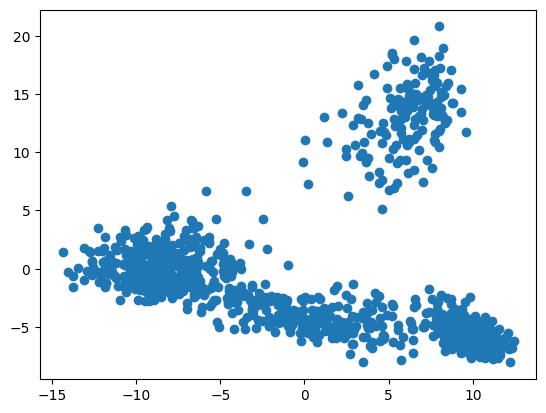

In [168]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(2)
res = pca.fit_transform(embeddings)
plt.scatter(res[:, 0], res[:, 1])
pca.explained_variance_ratio_